In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report

# Base models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier, VotingClassifier, StackingClassifier

# Boosting
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# Tuning
from sklearn.model_selection import GridSearchCV

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [59]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_sub = pd.read_csv('sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (8693, 14)
Test shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


##Khai phá dữ liệu :D

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 891.5+ KB
Missing in train:
 HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomSe

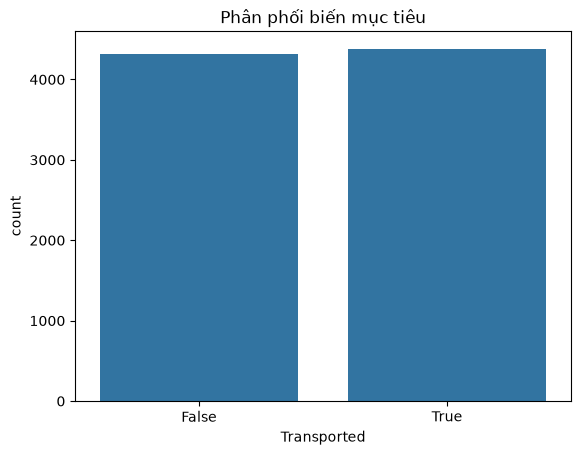

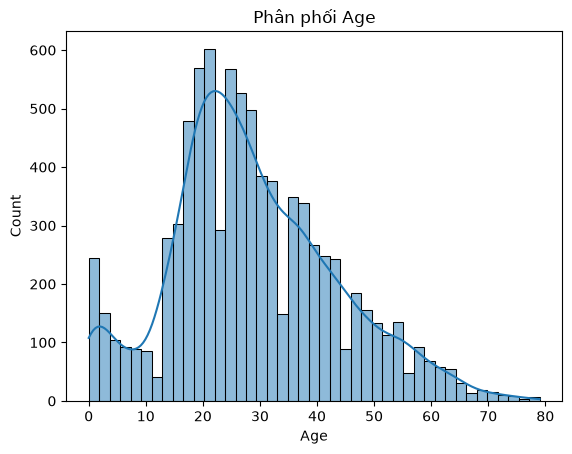

Cabin
G/734/S     8
E/13/S      7
B/11/S      7
C/21/P      7
G/109/P     7
B/82/S      7
C/137/S     7
F/1194/P    7
D/176/S     7
B/201/P     7
Name: count, dtype: int64

In [60]:
train.info()
train.describe(include='all')

missing_train = train.isnull().sum()
missing_test = test.isnull().sum()
print("Missing in train:\n", missing_train[missing_train>0])
print("\nMissing in test:\n", missing_test[missing_test>0])

sns.countplot(x='Transported', data=train)
plt.title('Phân phối biến mục tiêu')
plt.show()

# vd: Age
sns.histplot(train['Age'].dropna(), kde=True)
plt.title('Phân phối Age')
plt.show()

# Cabin có thể tách thành Deck, Number, Side
train['Cabin'].value_counts().head(10)

Preprocessing 1: 

Tách PassengerId thành Group và Number (vì id có dạng ggggg_nn)

Tách Cabin thành Deck (chữ cái đầu), Num (số), Side (P/S)

Tổng số tiền chi tiêu: TotalSpent = RoomService + FoodCourt + ShoppingMall + Spa + VRDeck

Số lượng dịch vụ đã sử dụng (ServiceCount)

In [61]:
def preprocess(df, is_train=True):
    df = df.copy()
    # Tách PassengerId
    df[['Group', 'Number']] = df['PassengerId'].str.split('_', expand=True)
    df['Group'] = df['Group'].astype(int)
    df['Number'] = df['Number'].astype(int)
    
    # Tách Cabin
    df['Deck'] = df['Cabin'].str[0]  # chữ cái đầu
    df['CabinNum'] = df['Cabin'].str[1:].str.extract('(\d+)').astype(float)
    df['Side'] = df['Cabin'].str[-1]  # P hoặc S
    
    # Tổng chi tiêu
    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpent'] = df[spend_cols].sum(axis=1)
    
    # Số dịch vụ đã dùng (chi tiêu >0)
    df['ServiceCount'] = (df[spend_cols] > 0).sum(axis=1)
    
    # Các đặc trưng khác
    df['Age'] = df['Age'].fillna(df['Age'].median())
    # Nếu VIP thì có thể ảnh hưởng
    df['VIP'] = df['VIP'].fillna(False).astype(int)
    df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(int)
    
    # Xóa các cột không cần thiết (trừ mục tiêu)
    drop_cols = ['PassengerId', 'Name', 'Cabin']  # đã tách
    if is_train:
        # không xóa Transported
        pass
    else:
        drop_cols = ['PassengerId', 'Name', 'Cabin']
    df.drop(columns=drop_cols, inplace=True, errors='ignore')
    
    # Xử lý HomePlanet và Destination (encode later)
    return df

train_processed = preprocess(train, is_train=True)
test_processed = preprocess(test, is_train=False)

train_processed.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Group,Number,Deck,CabinNum,Side,TotalSpent,ServiceCount
0,Europa,0,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,False,1,1,B,0.0,P,0.0,0
1,Earth,0,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,True,2,1,F,0.0,S,736.0,5
2,Europa,0,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,3,1,A,0.0,S,10383.0,4
3,Europa,0,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,3,2,A,0.0,S,5176.0,4
4,Earth,0,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,True,4,1,F,1.0,S,1091.0,5


In [62]:
# Tách X, y
X = train_processed.drop('Transported', axis=1)
y = train_processed['Transported'].astype(int)
X_test = test_processed.copy()

# Xác định cột
cat_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
num_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
            'Group', 'Number', 'CabinNum', 'TotalSpent', 'ServiceCount']
bin_cols = ['CryoSleep', 'VIP']

for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X[col] = le.transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

for col in X.columns:
    if X[col].dtype in ['float64', 'int64']:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna(X[col].median())
    else:
        if X[col].isnull().sum() > 0:
            X[col] = X[col].fillna('Unknown')

for col in X_test.columns:
    if X_test[col].dtype in ['float64', 'int64']:
        if X_test[col].isnull().sum() > 0:
            X_test[col] = X_test[col].fillna(X[col].median())
    else:
        if X_test[col].isnull().sum() > 0:
            X_test[col] = X_test[col].fillna('Unknown')

print("NaN trong X sau xử lý:", X.isnull().sum().sum())
print("NaN trong X_test sau xử lý:", X_test.isnull().sum().sum())

NaN trong X sau xử lý: 0
NaN trong X_test sau xử lý: 0


Standardize

In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[num_cols])
X_test_scaled = scaler.transform(X_test[num_cols])

X_final = pd.DataFrame(X_scaled, columns=num_cols)
X_test_final = pd.DataFrame(X_test_scaled, columns=num_cols)

for col in cat_cols + bin_cols:
    X_final[col] = X[col].values
    X_test_final[col] = X_test[col].values


In [64]:
X_train, X_val, y_train, y_val = train_test_split(X_final, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape, "Val size:", X_val.shape)

Train size: (6954, 17) Val size: (1739, 17)


Thử lần lượt:

Logistic Regression

Random Forest

XGBoost

LightGBM

CatBoost

SVM (tuyến tính)

In [65]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, 
                                  use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'CatBoost': cb.CatBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42, 
                                       verbose=0, cat_features=[]),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

Đánh giá trên validation

LogisticRegression: Accuracy = 0.7867
RandomForest: Accuracy = 0.7999
XGBoost: Accuracy = 0.8074
LightGBM: Accuracy = 0.8091
CatBoost: Accuracy = 0.7999
SVM: Accuracy = 0.7861


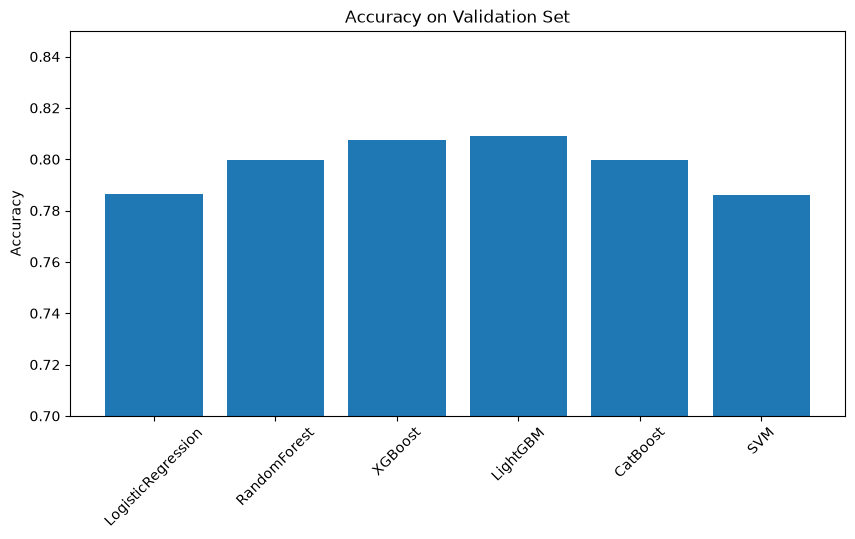

In [66]:
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {acc:.4f}")

# Trực quan hóa
plt.figure(figsize=(10,5))
plt.bar(results.keys(), results.values())
plt.ylim(0.7, 0.85)
plt.title('Accuracy on Validation Set')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

Voting classifier (soft voting)

In [67]:
voting_clf = VotingClassifier(estimators=[
    ('lr', models['LogisticRegression']),
    ('rf', models['RandomForest']),
    ('xgb', models['XGBoost']),
    ('lgb', models['LightGBM']),
    ('svm', models['SVM'])
], voting='soft', n_jobs=-1)

voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_val)
acc_voting = accuracy_score(y_val, y_pred_voting)
print(f"Voting Classifier Accuracy: {acc_voting:.4f}")

Voting Classifier Accuracy: 0.8056


stacking classifier

In [68]:
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, 
                              use_label_encoder=False, eval_metric='logloss')),
    ('lgb', lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(estimators=base_models, final_estimator=meta_model, cv=3, n_jobs=-1)
stacking_clf.fit(X_train, y_train)
y_pred_stacking = stacking_clf.predict(X_val)
acc_stacking = accuracy_score(y_val, y_pred_stacking)
print(f"Stacking Classifier Accuracy: {acc_stacking:.4f}")

Stacking Classifier Accuracy: 0.8120


bagging feat. decision tree

In [69]:
bagging_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)
bagging_clf.fit(X_train, y_train)
y_pred_bagging = bagging_clf.predict(X_val)
acc_bagging = accuracy_score(y_val, y_pred_bagging)
print(f"Bagging Classifier Accuracy: {acc_bagging:.4f}")

Bagging Classifier Accuracy: 0.8056


adaboost

In [70]:
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
ada_clf.fit(X_train, y_train)
y_pred_ada = ada_clf.predict(X_val)
acc_ada = accuracy_score(y_val, y_pred_ada)
print(f"AdaBoost Classifier Accuracy: {acc_ada:.4f}")

AdaBoost Classifier Accuracy: 0.7504



Bảng độ chính xác:
                    Accuracy  Rank
Stacking            0.811961     1
LightGBM            0.809086     2
XGBoost             0.807361     3
Voting              0.805635     4
Bagging             0.805635     5
RandomForest        0.799885     6
CatBoost            0.799885     7
LogisticRegression  0.786659     8
SVM                 0.786084     9
AdaBoost            0.750431    10


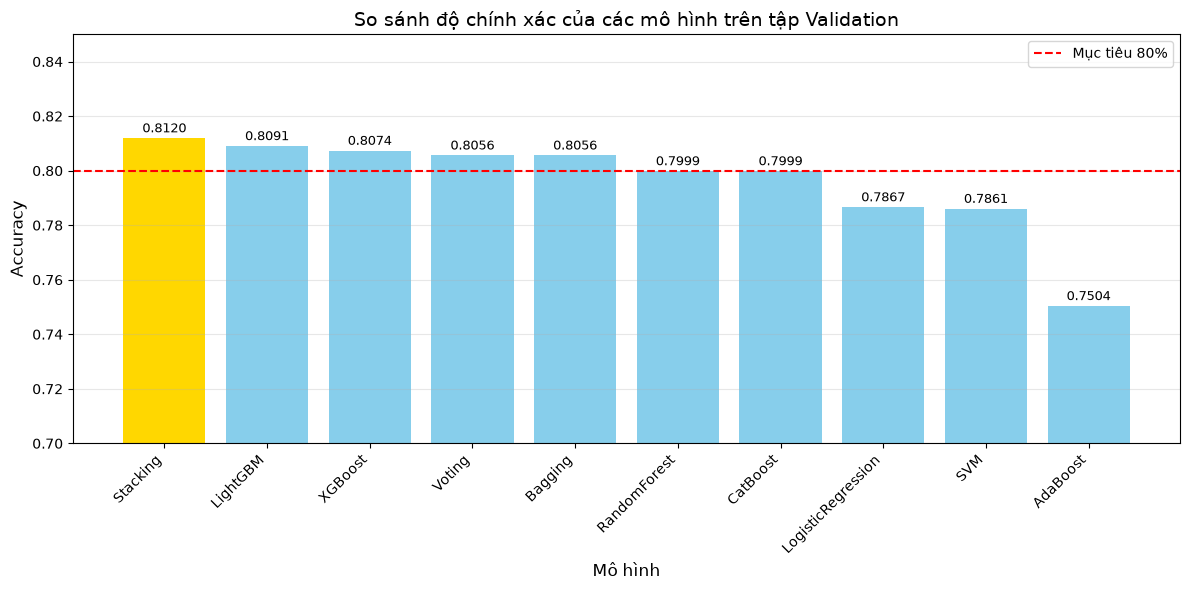

In [71]:
# Gộp tất cả kết quả
all_results = {}
all_results.update(results)  # Các mô hình cơ sở
all_results['Voting'] = acc_voting
all_results['Stacking'] = acc_stacking
all_results['Bagging'] = acc_bagging
all_results['AdaBoost'] = acc_ada

# Tạo DataFrame để so sánh
comparison_df = pd.DataFrame.from_dict(all_results, orient='index', columns=['Accuracy'])
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)
comparison_df['Rank'] = range(1, len(comparison_df) + 1)

print("\nBảng độ chính xác:")
print(comparison_df)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
bars = plt.bar(comparison_df.index, comparison_df['Accuracy'], 
               color=['gold' if i == 0 else 'skyblue' for i in range(len(comparison_df))])
plt.axhline(y=0.80, color='red', linestyle='--', label='Mục tiêu 80%')
plt.title('So sánh độ chính xác của các mô hình trên tập Validation', fontsize=14)
plt.xlabel('Mô hình', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.70, 0.85)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Thêm giá trị lên đầu cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Dự đoán trên test + tạo submission

In [72]:
best_model_name = max(all_results, key=all_results.get)
print(f"Mô hình tốt nhất: {best_model_name} với Accuracy = {all_results[best_model_name]:.4f}")

# Xác định mô hình tương ứng
if best_model_name == 'Voting':
    best_model = voting_clf
elif best_model_name == 'Stacking':
    best_model = stacking_clf
elif best_model_name == 'Bagging':
    best_model = bagging_clf
elif best_model_name == 'AdaBoost':
    best_model = ada_clf
elif best_model_name in ['XGBoost_Optimized', 'RandomForest_Optimized', 'LightGBM_Optimized']:
    best_model = grid_search.best_estimator_
elif best_model_name in models:
    best_model = models[best_model_name]
else:
    # Mặc định dùng Stacking
    print("Sử dụng Stacking Classifier làm mô hình mặc định")
    best_model = stacking_clf

print(f"\nĐang huấn luyện lại {best_model_name} trên toàn bộ dữ liệu train...")
# Train lại trên toàn bộ dữ liệu
best_model.fit(X_final, y)

# Dự đoán trên test
print("Đang dự đoán trên tập test...")
try:
    # Thử dự đoán xác suất
    y_test_proba = best_model.predict_proba(X_test_final)[:, 1]
    y_test_pred = (y_test_proba > 0.5)
except:
    # Nếu không có predict_proba, dùng predict
    y_test_pred = best_model.predict(X_test_final)
    y_test_proba = None

# Tạo submission
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': y_test_pred
})

# Đảm bảo kiểu dữ liệu đúng
submission['Transported'] = submission['Transported'].astype(bool)

# Lưu file
submission.to_csv('submission.csv', index=False)
print("\nĐã tạo file submission.csv thành công!")
print(f"Shape: {submission.shape}")
print("\n5 dòng đầu tiên:")
print(submission.head())

# Hiển thị phân phối dự đoán
print(f"\nPhân phối dự đoán:")
print(submission['Transported'].value_counts())
print(f"Tỷ lệ True: {submission['Transported'].mean():.2%}")

Mô hình tốt nhất: Stacking với Accuracy = 0.8120

Đang huấn luyện lại Stacking trên toàn bộ dữ liệu train...
Đang dự đoán trên tập test...

Đã tạo file submission.csv thành công!
Shape: (4277, 2)

5 dòng đầu tiên:
  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01         True
4     0023_01        False

Phân phối dự đoán:
Transported
True     2208
False    2069
Name: count, dtype: int64
Tỷ lệ True: 51.62%
